# 1단계: 오피스 구역 분류

**목적:** 야근 가능성이 높은 오피스 밀집 행정동 식별 → 오피스밀집도 지수 산출

**활용 데이터:**
- `2024년 기준 사업체조사 자료.csv` — 통계청 전국사업체조사 (공개, 서울 전체)
- `bnd_dong_11_2025_2Q.shp` — SGIS 행정구역경계(읍면동)

**컬럼 구조 (사업체조사):**
- `AD_CD`: 행정구역분류부호 (행정동코드 8자리)
- `INDST_LCLS_CD`: 산업대분류 코드 (A~S, 한국표준산업분류 11차)
- `SURV_PHS_WOKE_SUM`: 전체 종사자 합계

**야근 가능성 높은 업종 (오피스 대분류):**
- J: 정보통신업 / K: 금융 및 보험업 / M: 전문·과학·기술 서비스업
- N: 사업시설 관리·사업지원 서비스업 / L: 부동산업

**산출물:** output/stage01_office_index.csv + output/01_office_heatmap.png

**반출 주의사항:**
- 원시 데이터 출력(head 등) 제거 완료
- 지도: geopandas PNG 저장 (HTML 반출 불가)
- CSV 반출 시 반출신청서에 출처·산출과정 명시 필요


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR   = 'data/'
OUTPUT_DIR = 'output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('라이브러리 로드 완료')


라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
# ── 사업체조사 데이터 로드 (usecols로 필요한 3개 컬럼만 읽기 → 메모리 절약)
# 파일: 2024년 기준 사업체조사 자료.csv
# 인코딩: utf-8-sig / 컬럼: 영문코드 기반

BUSI_FILE = DATA_DIR + '2024년 기준 사업체조사 자료.csv'

df_raw = pd.read_csv(
    BUSI_FILE,
    encoding='utf-8-sig',
    usecols=['AD_CD', 'INDST_LCLS_CD', 'SURV_PHS_WOKE_SUM'],
    dtype={'AD_CD': str, 'INDST_LCLS_CD': str}
)
df_raw['SURV_PHS_WOKE_SUM'] = pd.to_numeric(df_raw['SURV_PHS_WOKE_SUM'], errors='coerce').fillna(0)

# 행정동코드 8자리 맞추기
df_raw['행정동코드'] = df_raw['AD_CD'].str.zfill(8)

print(f'로드 완료: {len(df_raw):,}행')
print(f'산업대분류 종류: {sorted(df_raw["INDST_LCLS_CD"].unique())}')
print(f'행정동 수: {df_raw["행정동코드"].nunique()}개')


로드 완료: 1,176,066행
산업대분류 종류: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S']
행정동 수: 426개


In [3]:
# ── 행정동 경계 Shapefile 로드
# 파일 위치: data/bnd_dong_11_2025_2Q.shp (.shp/.dbf/.shx/.prj 4개 필요)
gdf_dong = gpd.read_file(DATA_DIR + 'bnd_dong_11_2025_2Q.shp')
if gdf_dong.crs is None or gdf_dong.crs.to_epsg() != 4326:
    gdf_dong = gdf_dong.to_crs('EPSG:4326')

# 행정동코드 컬럼 자동 탐색 (ADM_CD, ADMD_CD 등 다양한 이름 대응)
dong_code_col = next(
    (c for c in gdf_dong.columns if any(k in c for k in ['행정동코드','ADM_CD','ADMD_CD','EMD_CD','dong_cd'])),
    gdf_dong.columns[0]
)
dong_name_col = next(
    (c for c in gdf_dong.columns if any(k in c for k in ['행정동명','ADM_NM','ADMD_NM','EMD_NM','dong_nm'])),
    None
)
gdf_dong = gdf_dong.rename(columns={dong_code_col: '행정동코드'})
if dong_name_col:
    gdf_dong = gdf_dong.rename(columns={dong_name_col: '행정동명'})

gdf_dong['행정동코드'] = gdf_dong['행정동코드'].astype(str).str.zfill(8)
print(f'행정동 경계 로드 완료: {len(gdf_dong)}개 동')
print(f'컬럼: {gdf_dong.columns.tolist()}')
print(f'좌표계: {gdf_dong.crs}')


행정동 경계 로드 완료: 426개 동
컬럼: ['BASE_DATE', '행정동코드', '행정동명', 'geometry']
좌표계: EPSG:4326


## 2. 야근 가능성 높은 업종 필터링

In [4]:
# ── 야근 가능성 높은 업종 필터링
# 한국표준산업분류(KSIC) 11차 대분류 기준
OFFICE_INDUSTRIES = {
    'J': '정보통신업',
    'K': '금융 및 보험업',
    'M': '전문·과학·기술 서비스업',
    'N': '사업시설 관리·사업지원 서비스업',
    'L': '부동산업',
}

# 전체 행정동별 종사자 합계
df_total = (df_raw.groupby('행정동코드')['SURV_PHS_WOKE_SUM']
                  .sum().reset_index()
                  .rename(columns={'SURV_PHS_WOKE_SUM': '전체_종사자수'}))

# 오피스 업종만 필터 → 행정동별 합산
df_office = (df_raw[df_raw['INDST_LCLS_CD'].isin(OFFICE_INDUSTRIES.keys())]
               .groupby('행정동코드')['SURV_PHS_WOKE_SUM']
               .sum().reset_index()
               .rename(columns={'SURV_PHS_WOKE_SUM': '오피스_종사자수'}))

print(f'전체 행정동: {len(df_total)}개')
print(f'오피스 업종 종사자 있는 행정동: {len(df_office)}개')


전체 행정동: 426개
오피스 업종 종사자 있는 행정동: 426개


## 3. Min-Max 정규화 → 오피스 밀집도 지수 산출

In [5]:
# ── 병합 및 Min-Max 정규화 → 오피스 밀집도 지수 산출
df_merged = df_total.merge(df_office, on='행정동코드', how='left')
df_merged['오피스_종사자수'] = df_merged['오피스_종사자수'].fillna(0)

# 오피스 업종 종사자 비율 (밀집도 지표)
df_merged['오피스_비율'] = (
    df_merged['오피스_종사자수'] / df_merged['전체_종사자수'].replace(0, np.nan)
).fillna(0)

# Min-Max 정규화 → 오피스 밀집도 지수 (0~1)
scaler = MinMaxScaler()
df_merged['오피스_밀집도_지수'] = scaler.fit_transform(
    df_merged[['오피스_종사자수']]  # 절대량 기준 정규화
)

# 행정동명 병합
if '행정동명' in gdf_dong.columns:
    df_merged = df_merged.merge(
        gdf_dong[['행정동코드', '행정동명']], on='행정동코드', how='left'
    )

print(f'오피스 밀집도 지수 산출 완료: {len(df_merged)}개 행정동')

# 상위 10개 확인 (집계 건수만)
top10 = df_merged.nlargest(10, '오피스_밀집도_지수')
if '행정동명' in df_merged.columns:
    print('\n[오피스 밀집도 상위 10개 행정동]')
    print(top10[['행정동명', '오피스_종사자수', '오피스_밀집도_지수']].to_string(index=False))
else:
    print('\n[오피스 밀집도 상위 10개 행정동코드]')
    print(top10[['행정동코드', '오피스_종사자수', '오피스_밀집도_지수']].to_string(index=False))


오피스 밀집도 지수 산출 완료: 426개 행정동

[오피스 밀집도 상위 10개 행정동]
       행정동명  오피스_종사자수  오피스_밀집도_지수
        여의동    136466    1.000000
        가산동    106631    0.781204
       역삼1동    105551    0.773284
         명동     71930    0.526723
       구로3동     57740    0.422661
       서초3동     50685    0.370923
종로1·2·3·4가동     50446    0.369170
       서초2동     49169    0.359805
       가양1동     47259    0.345798
        소공동     44975    0.329048


## 4. 공간 데이터 결합 및 시각화

In [6]:
# ── GeoDataFrame에 밀집도 지수 병합
gdf_office = gdf_dong.merge(df_merged[['행정동코드','오피스_종사자수','오피스_밀집도_지수']],
                             on='행정동코드', how='left')
gdf_office['오피스_밀집도_지수'] = gdf_office['오피스_밀집도_지수'].fillna(0)
print(f'공간 데이터 병합 완료: {len(gdf_office)}개 행정동')


공간 데이터 병합 완료: 426개 행정동


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


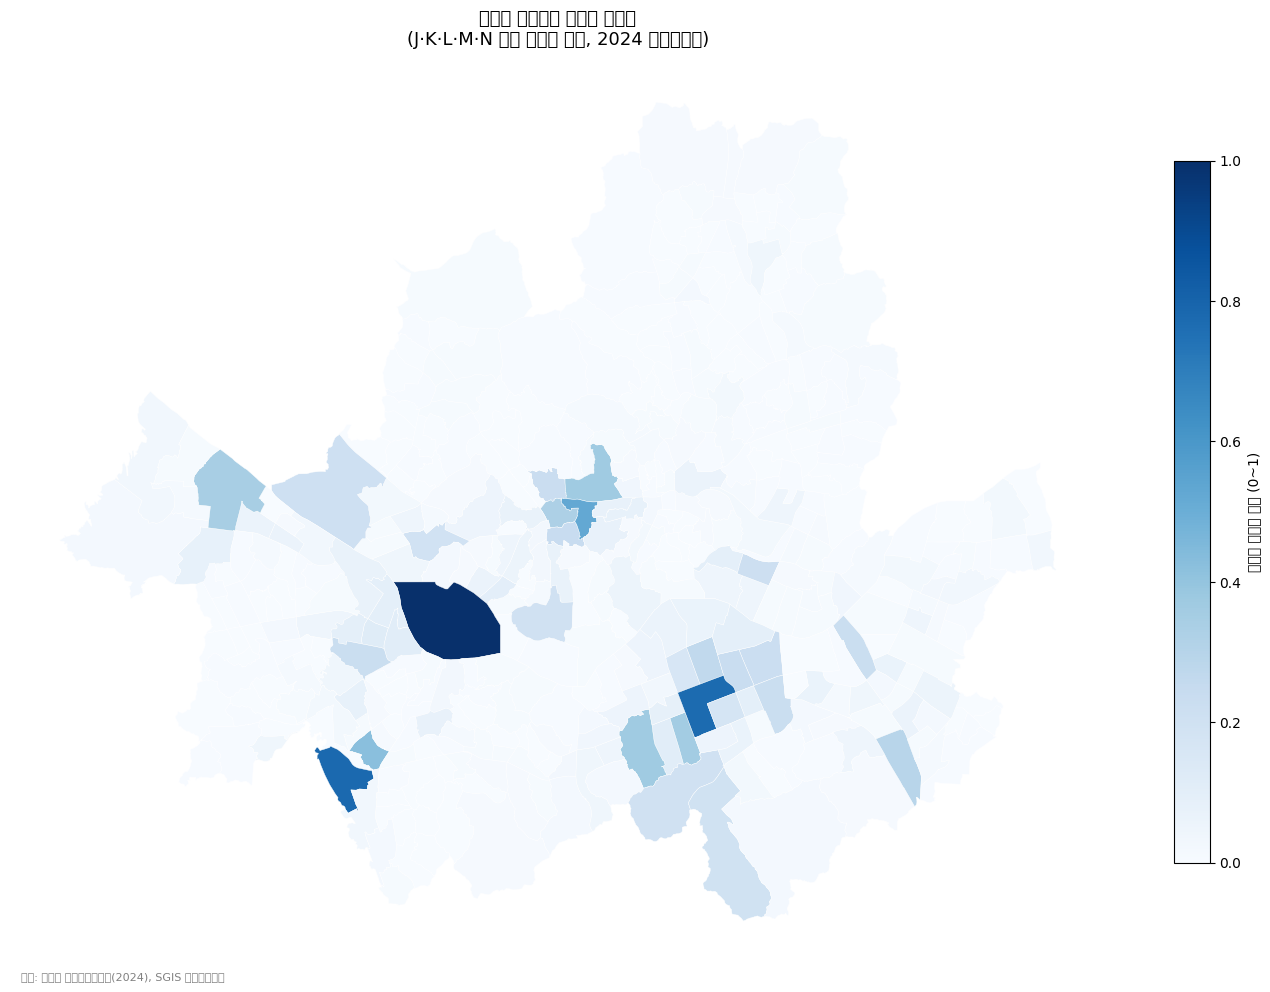

지도 저장 완료 → output/01_office_heatmap.png


In [7]:
# ── 오피스 밀집도 등치도 (geopandas PNG — 반출 가능)
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_office.plot(
    column='오피스_밀집도_지수',
    ax=ax,
    cmap='Blues',
    legend=True,
    legend_kwds={'label': '오피스 밀집도 지수 (0~1)', 'shrink': 0.6},
    edgecolor='white',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey'}
)
ax.set_title('서울시 행정동별 오피스 밀집도\n(J·K·L·M·N 업종 종사자 기준, 2024 사업체조사)', fontsize=13, pad=12)
ax.axis('off')
ax.text(0.01, -0.02, '출처: 통계청 전국사업체조사(2024), SGIS 행정구역경계',
        transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_office_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('지도 저장 완료 → output/01_office_heatmap.png')


## 5. 결과 저장 (다음 단계에서 사용)

In [8]:
# ── 결과 저장 (2·4단계에서 사용)
# 반출: 행정동 단위 응용집계 → 반출신청서에 출처 명시
cols = ['행정동코드', '오피스_종사자수', '전체_종사자수', '오피스_비율', '오피스_밀집도_지수']
if '행정동명' in df_merged.columns:
    cols.insert(1, '행정동명')

df_out = df_merged[cols].copy()
df_out.to_csv(OUTPUT_DIR + 'stage01_office_index.csv', index=False, encoding='utf-8-sig')
print(f'1단계 결과 저장 완료 → output/stage01_office_index.csv')
print(f'총 {len(df_out)}개 행정동 오피스 밀집도 지수 산출')
print('출처: 통계청 전국사업체조사(2024) 응용집계')


1단계 결과 저장 완료 → output/stage01_office_index.csv
총 426개 행정동 오피스 밀집도 지수 산출
출처: 통계청 전국사업체조사(2024) 응용집계
